# <center>Organizaci&oacute;n de Datos</center>
#### <center>C&aacute;tedra Ing. Rodriguez, Juan Manuel </center>

## <center>Experimento multicolinealidad en Regresión Lineal</center>
### <center> Práctica Reducción de dimensionalidad  </center>


En esta notebook vamos a analizar el comportamiento de un algoritmo de regresión lineal frente a multicolinealidad en sus variables para evaluar reducir dimensiones

Links:

https://scikit-learn.org/stable/

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

https://seaborn.pydata.org/tutorial/color_palettes.html

https://seaborn.pydata.org/generated/seaborn.heatmap.html


## Librerias

In [1]:
#Manipulacion de datos y funciones matemáticas
import pandas as pd
import numpy as np

#Visualizaciones
import seaborn as sns
import matplotlib.pyplot as plt

#Modelo Lineal
from sklearn.linear_model import LinearRegression

#Metricas para evaluar modelos
from sklearn import metrics

## Experimiento

Vamos a trabajar con un conjunto de datos de una empresa que contiene los ingresos (en millones) conseguidos por ventas en 200 regiones y la cantidad de presupuesto (en millones) destinado a anuncios por radio, TV y periódicos en cada una de ellas.

El departamento de ventas quiere estudiar la influencia que tiene la publicidad a través de distintos canales sobre las ventas de la empresa.

Nota: en este notebook vamos a omitir el análisis exploratorio del dataset, los invitamos a practicarlo como tarea ;)

In [2]:
publicidad=pd.read_csv('https://drive.google.com/uc?export=download&id=1Mbw00vnw4F8dg6pyGSh-F19zuKdxCwl3')
publicidad.head()

,tv,radio,periodico,ventas
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
publicidad.shape

(159, 4)

Veamos las variables en un gráfico de a pares:

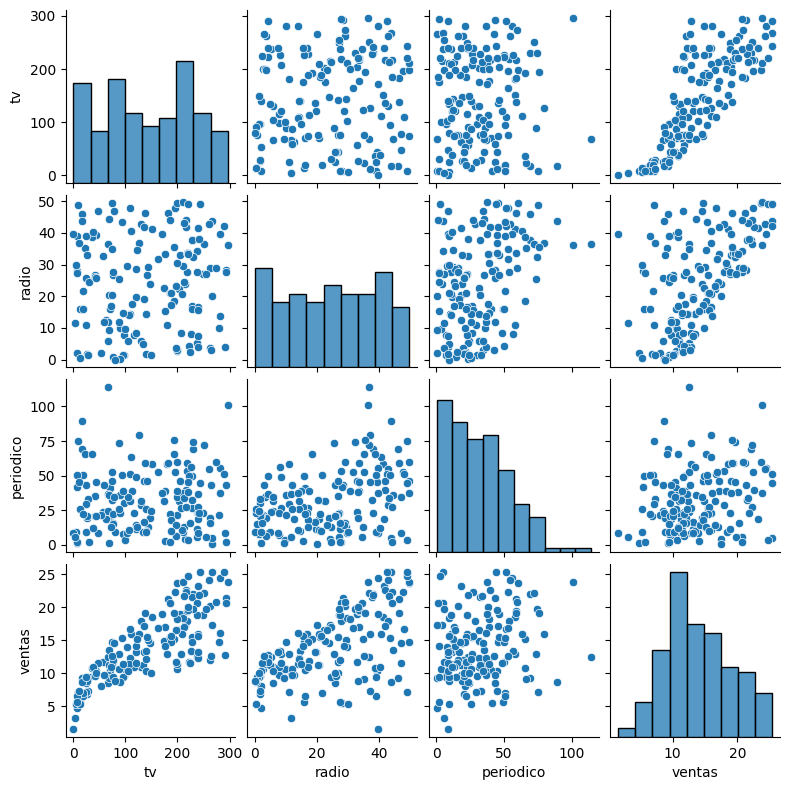

In [4]:
sns.pairplot(publicidad, height=2)

Analicemos la correlacion original lineal de las variables:

<Axes: >

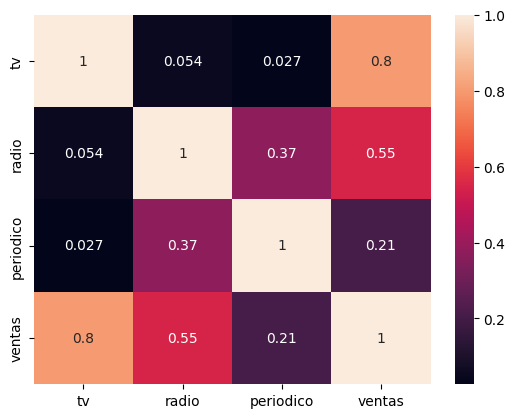

In [5]:
sns.heatmap(publicidad.corr(),annot=True)

## Modelo Lineal Múltiple

En un modelo lineal múltiple tenemos más de una variable predictora:

$𝑌$ $\approx$ $β_{0}$ + $β_{1}$ * $𝑋_{1}$ + $β_{2}$ * $𝑋_{2}$ + ...+ $β_{n}$ * $𝑋_{n}$

In [6]:
ds_publicidad_train=pd.read_csv('https://drive.google.com/uc?export=download&id=1Mbw00vnw4F8dg6pyGSh-F19zuKdxCwl3')
ds_publicidad_test=pd.read_csv('https://drive.google.com/uc?export=download&id=1cNLdknFhHquhWZndvSarMS6YA0JY4-49')

Genero columnas multicorrelacionadas

In [7]:
import random

mu = 0
sigma = 0.5


cant_vars_cor=9
nuevas_variables=[]
campos_nuevos=[]

for i in range(1,cant_vars_cor+1):
  sigma=0.05*i
  var_train=[ random.gauss(mu, sigma) for _ in range(0,ds_publicidad_train.shape[0]) ]
  var_test=[ random.gauss(mu, sigma) for _ in range(0,ds_publicidad_test.shape[0]) ]

  nombre_campo="tv_cor_"+str(i)
  campos_nuevos.append(nombre_campo)

  ds_publicidad_train[nombre_campo]=ds_publicidad_train['tv']+var_train
  ds_publicidad_test[nombre_campo]=ds_publicidad_test['tv']+var_test

  nuevas_variables.append(nombre_campo)

print(nuevas_variables)

['tv_cor_1', 'tv_cor_2', 'tv_cor_3', 'tv_cor_4', 'tv_cor_5', 'tv_cor_6', 'tv_cor_7', 'tv_cor_8', 'tv_cor_9']


In [8]:
ds_publicidad_train.head()

,tv,radio,periodico,ventas,tv_cor_1,tv_cor_2,tv_cor_3,tv_cor_4,tv_cor_5,tv_cor_6,tv_cor_7,tv_cor_8,tv_cor_9
0,230.1,37.8,69.2,22.1,230.161770,229.950063,230.208960,229.851215,230.268027,230.305296,230.665095,229.940431,230.321702
1,44.5,39.3,45.1,10.4,44.485878,44.534474,44.575882,44.521796,44.472788,44.467748,44.980091,44.942088,43.698645
2,17.2,45.9,69.3,9.3,17.245333,17.246601,17.205775,16.830254,17.070575,17.075171,17.153029,16.920974,16.388383
3,151.5,41.3,58.5,18.5,151.550109,151.401845,151.438762,151.562600,151.511548,151.499459,152.031026,151.608650,151.737517
4,180.8,10.8,58.4,12.9,180.815029,180.565257,180.838435,180.829381,180.516843,180.524161,180.254882,180.696135,180.218489


In [9]:
ds_publicidad_test.head()

,tv,radio,periodico,ventas,tv_cor_1,tv_cor_2,tv_cor_3,tv_cor_4,tv_cor_5,tv_cor_6,tv_cor_7,tv_cor_8,tv_cor_9
0,131.7,18.4,34.6,12.9,131.714000,131.777088,131.597019,131.689369,131.695802,132.270656,131.867592,131.414997,130.866207
1,172.5,18.1,30.7,14.4,172.442073,172.322257,172.815661,172.220435,172.503843,172.653435,172.403315,172.583631,172.661096
2,85.7,35.8,49.3,13.3,85.639669,85.794582,85.589202,85.932820,86.144317,85.937086,85.159088,85.813539,85.799966
3,188.4,18.1,25.6,14.9,188.395232,188.333720,188.440611,188.557645,188.388736,188.542848,188.519056,189.201506,187.723609
4,163.5,36.8,7.4,18.0,163.439817,163.574958,163.535487,163.880562,163.739852,163.682359,163.850583,163.427074,163.582172


In [10]:
ds_publicidad_train.corr()

,tv,radio,periodico,ventas,tv_cor_1,tv_cor_2,tv_cor_3,tv_cor_4,tv_cor_5,tv_cor_6,tv_cor_7,tv_cor_8,tv_cor_9
tv,1.000000,0.054495,0.026783,0.801877,1.000000,0.999999,0.999998,0.999997,0.999995,0.999994,0.999991,0.999990,0.999986
radio,0.054495,1.000000,0.373838,0.546087,0.054526,0.054439,0.054431,0.054350,0.054147,0.054383,0.054852,0.054321,0.053842
periodico,0.026783,0.373838,1.000000,0.205542,0.026882,0.026754,0.026810,0.026824,0.026367,0.026663,0.026978,0.027078,0.025938
ventas,0.801877,0.546087,0.205542,1.000000,0.801887,0.801861,0.801876,0.801781,0.801747,0.801810,0.801867,0.801651,0.801376
tv_cor_1,1.000000,0.054526,0.026882,0.801887,1.000000,0.999999,0.999998,0.999997,0.999995,0.999994,0.999991,0.999990,0.999986
tv_cor_2,0.999999,0.054439,0.026754,0.801861,0.999999,1.000000,0.999998,0.999996,0.999994,0.999993,0.999991,0.999989,0.999986
tv_cor_3,0.999998,0.054431,0.026810,0.801876,0.999998,0.999998,1.000000,0.999996,0.999994,0.999994,0.999989,0.999988,0.999985
tv_cor_4,0.999997,0.054350,0.026824,0.801781,0.999997,0.999996,0.999996,1.000000,0.999992,0.999992,0.999988,0.999987,0.999984
tv_cor_5,0.999995,0.054147,0.026367,0.801747,0.999995,0.999994,0.999994,0.999992,1.000000,0.999991,0.999986,0.999984,0.999981
tv_cor_6,0.999994,0.054383,0.026663,0.801810,0.999994,0.999993,0.999994,0.999992,0.999991,1.000000,0.999985,0.999983,0.999982


### Ajuste del Modelo

Creamos un modelo con todas las variables y evaluamos los resultados

In [11]:
#Creo un regresor lineal
modelo_lineal_multiple = LinearRegression()

#Doy el formato adecuado a las variables dependiente e independiente

campos=['tv','radio']+campos_nuevos
medios=ds_publicidad_train[campos]
ventas=ds_publicidad_train['ventas'].values.reshape(-1, 1)

#Ajusto el modelo
modelo_lineal_multiple.fit(medios,ventas)


LinearRegression()

In [12]:
print(campos)
for i in range(0,len(campos)):
  print(round(modelo_lineal_multiple.coef_[0][i],2))

round(modelo_lineal_multiple.intercept_[0],2)

['tv', 'radio', 'tv_cor_1', 'tv_cor_2', 'tv_cor_3', 'tv_cor_4', 'tv_cor_5', 'tv_cor_6', 'tv_cor_7', 'tv_cor_8', 'tv_cor_9']
-0.45
0.18
0.2
0.89
0.52
-0.12
0.25
-0.01
-0.54
-0.3
-0.39


2.94

### Evaluación de las métricas del modelo ajustado

In [13]:
#R2
r2=modelo_lineal_multiple.score(medios,ventas)
print(f"El R2 del modelo multiple es: {r2}")

El R2 del modelo multiple es: 0.9001437603265751


In [14]:
#R2 Ajustado
n=publicidad.shape[0] #numero de observaciones
p=2                   #numero de variables independientes

adj_r2 = 1-(1-r2)*(n-1)/(n-p-1)
adj_r2

0.8988635521256337

In [15]:
#RMSE

ventas_pred=modelo_lineal_multiple.predict(ds_publicidad_train[campos])

rmse = metrics.mean_squared_error(
        y_true  = ventas,
        y_pred  = ventas_pred,
        squared = False
       )

print(f"El error (rmse) del modelo multiple es: {rmse}")

El error (rmse) del modelo multiple es: 1.652133078541654


### Prediccion y Evaluación en datos de testeo

In [16]:
#Casos nuevos

medios_test=ds_publicidad_test[campos]

#Variable a predecir
ventas_test=ds_publicidad_test['ventas'].values.reshape(-1,1)

#Prediccion sobre casos nuevos con mis modelos ya entrenados
ventas_predict_medios    =  modelo_lineal_multiple.predict(medios_test)

In [17]:
print('Modelo Múltiple:')

mse = metrics.mean_squared_error(
        y_true  = ventas_test,
        y_pred  = ventas_predict_medios,
        squared = True
       )

print(f"El error (mse) de test es: {mse}")


rmse = metrics.mean_squared_error(
        y_true  = ventas_test,
        y_pred  = ventas_predict_medios,
        squared = False
       )

print(f"El error (rmse) de test es: {rmse}")

Modelo Múltiple:
El error (mse) de test es: 2.5147108036172665
El error (rmse) de test es: 1.5857839712953548
